# Notebook 2 — Mary's biopsy and the Process-Role-Object pattern
## Naming participants without inventing new properties

On 2026-02-25 Mary returns to the clinic for a **core needle biopsy of the left breast**. A radiologist, holding a biopsy needle, removes a small cylinder of tissue from her left breast. After the procedure, five participants are involved:

1. **Mary** — the *subject* on whom the procedure is performed
2. **The radiologist** — the *agent* who plans and executes the procedure
3. **The biopsy needle** — the *instrument* that mediates the procedure
4. **The left breast** — the *location* at which the procedure occurs
5. **The tissue specimen** — the *output* that did not exist before the procedure began

The temptation is to invent five properties — `hasSubject`, `hasAgent`, `hasInstrument`, `hasLocation`, `hasOutput` — and litter the ontology with them. SULO takes the opposite route: **a single participation property**, `sulo:hasParticipant`, and the typing of *how* an entity participates is moved into a reified intermediate — the **Role**. This is the Process-Role-Object (PRO) design pattern, and Mary's biopsy is the canonical example.

## Learning objectives

1. Understand why SULO ships only one participation property and how role reification recovers the expressivity of many role-specific properties
2. Import the PRO ontology (role taxonomy + two process subtypes) without adding any new object or data property to the MIE ontology
3. Type the participants of `SCT_CoreNeedleBiopsyOfBreast` at the *class level* using nested existential restrictions over `sulo:hasParticipant` and `sulo:isFeatureOf`
4. Define an equivalent class `ProcedureProducingTissueSpecimen` that classifies any transformation process whose output is a tissue specimen
5. Distinguish **persistent roles** (one individual per bearer, reused across many processes) from **event-bound roles** (one individual per process), and apply both correctly to Mary's individual biopsy
6. Contrast a `TransformationProcess` (biopsy) with a `DevelopmentalProcess` (follow-up visit), reusing Mary's persistent patient role across both

## What we will *not* do

- **No new properties.** This notebook adds only classes. Every relation used (`hasParticipant`, `isFeatureOf`, `hasDirectPart`, `atTime`, `hasValue`, `precedes`) is SULO's.
- **No repetition of the PRO drill.** The pattern is exercised once on the biopsy with full T-Box restrictions, then contrasted once on the follow-up. We will not re-type every other process in the odyssey; later notebooks will do so only when it earns a new lesson.

## Setting up

We reload SULO, load the PRO ontology, and reload the MIE checkpoint produced by NB1. Then we declare PRO as an imported ontology of MIE so that PRO classes are first-class citizens of subsequent axioms.

In [1]:
import sys, os, datetime
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append("dist")

sulo = get_ontology("dist/sulo.owl").load()
pro  = get_ontology("dist/pro.owl").load()
mie  = get_ontology("dist/mie-01.owl").load()
mie.imported_ontologies.append(pro)

print("PRO classes available for the PRO pattern:")
for c in sorted(pro.classes(), key=lambda c: c.name):
    parents = [p.name for p in c.is_a if hasattr(p, 'name')]
    print(f"  {c.name:25s} <- {parents}")

PRO classes available for the PRO pattern:
  AgentRole                 <- ['Role']
  ConsumedRole              <- ['PatientRole']
  DevelopmentRole           <- ['PatientRole']
  DevelopmentalProcess      <- ['Process']
  EmergingRole              <- ['Role']
  InstrumentRole            <- ['Role']
  LocationRole              <- ['Role']
  PatientRole               <- ['Role']
  PersistingRole            <- ['Role']
  TransformationProcess     <- ['Process']


## §1 — Why a single participation property?

Most clinical ontologies you will encounter use many participation properties: `hasPerformer`, `hasInstrument`, `hasAnatomicalSite`, `hasResult`, `hasSubject`, `hasReason`, … Every new procedure type that introduces a new kind of participant creates pressure to mint a new property. The result is *vocabulary sprawl*: hundreds of properties whose intended meanings overlap and whose alignment across institutions becomes a permanent maintenance burden.

SULO takes a different stance. Every participant of a process is linked via the **single** property `sulo:hasParticipant`. Distinguishing *how* the entity participates is the job of an intermediate **Role** entity: the role is `sulo:isFeatureOf` the object that plays it, and the role's *type* (Agent, Instrument, Location, …) carries the participation semantics.

Concretely, the participation pattern reads as follows:

```
process  --sulo:hasParticipant-->  role  --sulo:isFeatureOf-->  object
```

Two relations, one pattern, arbitrarily many role *types*. New role types are introduced as classes — not as properties — and so the ontology's property vocabulary stays small even as its domain coverage grows. This is the move that lets a clinical ontology stay aligned with SULO without bringing in a thicket of domain-specific properties.

## §2 — What PRO ships

The PRO ontology (`https://w3id.org/ontostart/pro/`) bundles the role taxonomy plus two process subtypes that capture *what happens to participants*. The whole vocabulary, printed by the setup cell above, is:

| Class | Parent | Semantics |
|---|---|---|
| `AgentRole` | `sulo:Role` | Intentional initiator and controller of the process |
| `PatientRole` | `sulo:Role` | Undergoer of the effects of the process |
| `ConsumedRole` | `PatientRole` | Ceases to exist during the process |
| `DevelopmentRole` | `PatientRole` | Persists but changes qualities or sortal classification |
| `InstrumentRole` | `sulo:Role` | Mediates or enables the process, triggered by an agent |
| `LocationRole` | `sulo:Role` | The spatial region in which the process occurs |
| `PersistingRole` | `sulo:Role` | Persists unchanged across the process |
| `EmergingRole` | `sulo:Role` | Comes into existence during the process |
| `TransformationProcess` | `sulo:Process` | At least one participant is consumed and/or an output emerges |
| `DevelopmentalProcess` | `sulo:Process` | Participants persist; only their qualities or types change |

Crucially, **PRO declares zero new object or data properties**. The whole machinery is built on `sulo:hasParticipant` and `sulo:isFeatureOf`.

## §3 — Naming the participants

Before we can write the class-level restrictions for the biopsy, we need *names* for the participating objects. We will not yet open them up internally — Mary's anatomy is the subject of NB3, and the specimen's composition belongs to NB3 as well. Five placeholder `sulo:SpatialObject` subclasses suffice for now:

In [2]:
with mie:
    class Person(sulo.SpatialObject):
        """A human individual."""
        label = [locstr("person", "en")]

    class Physician(Person):
        """A person qualified and authorised to practise medicine."""
        label = [locstr("physician", "en")]

    class BiopsyNeedle(sulo.SpatialObject):
        """A hollow needle designed to extract a cylindrical core of tissue from a biological structure."""
        label = [locstr("biopsy needle", "en")]

    class Breast(sulo.SpatialObject):
        """A mammary gland with associated adipose tissue, skin, and nipple — internal structure is added in NB3."""
        label = [locstr("breast", "en")]

    class TissueSpecimen(sulo.SpatialObject):
        """A fragment of biological tissue separated from a living organism for diagnostic examination."""
        label = [locstr("tissue specimen", "en")]

print(f"MIE classes now: {len(list(mie.classes()))}")
print(f"MIE object properties (local): {len(list(mie.object_properties()))}  ← still zero")

MIE classes now: 16
MIE object properties (local): 0  ← still zero


## §4 — Class-level role typing of the biopsy

We now express the *necessary* conditions for being a `SCT_CoreNeedleBiopsyOfBreast`. Two things happen in this cell.

**1. We add `pro:TransformationProcess` as a parent.** A biopsy is the canonical transformation: the tissue specimen does not exist before the procedure begins and does exist after it ends. This single sub-class axiom carries the ontological commitment that *something emerges*.

**2. We add five `is_a` restrictions** — one per participant kind — each of the form

```
hasParticipant some ( <RoleType> and isFeatureOf some <ObjectType> )
```

These are **necessary** conditions, not sufficient: every biopsy *must* have these five participants, but having all five does not by itself make a process a biopsy. (For sufficient conditions we would use `equivalent_to`, as we do for the defined class in §5.)

In [3]:
with mie:
    mie.SCT_CoreNeedleBiopsyOfBreast.is_a.append(pro.TransformationProcess)
    mie.SCT_CoreNeedleBiopsyOfBreast.is_a.extend([
        sulo.hasParticipant.some(pro.PatientRole    & sulo.isFeatureOf.some(Person)),
        sulo.hasParticipant.some(pro.AgentRole      & sulo.isFeatureOf.some(Physician)),
        sulo.hasParticipant.some(pro.InstrumentRole & sulo.isFeatureOf.some(BiopsyNeedle)),
        sulo.hasParticipant.some(pro.LocationRole   & sulo.isFeatureOf.some(Breast)),
        sulo.hasParticipant.some(pro.EmergingRole   & sulo.isFeatureOf.some(TissueSpecimen)),
    ])

print("SCT_CoreNeedleBiopsyOfBreast restrictions:")
for r in mie.SCT_CoreNeedleBiopsyOfBreast.is_a:
    print(f"  - {r}")

SCT_CoreNeedleBiopsyOfBreast restrictions:
  - sulo.Process
  - pro.TransformationProcess
  - sulo.hasParticipant.some(pro.PatientRole & sulo.isFeatureOf.some(mie-01.Person))
  - sulo.hasParticipant.some(pro.AgentRole & sulo.isFeatureOf.some(mie-01.Physician))
  - sulo.hasParticipant.some(pro.InstrumentRole & sulo.isFeatureOf.some(mie-01.BiopsyNeedle))
  - sulo.hasParticipant.some(pro.LocationRole & sulo.isFeatureOf.some(mie-01.Breast))
  - sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(mie-01.TissueSpecimen))


## §5 — A defined class: `ProcedureProducingTissueSpecimen`

The five necessary conditions on the biopsy are powerful enough that we can identify a more general class that *any* transformation process producing a tissue specimen would satisfy. We define it as an **equivalent class** — the conditions are necessary *and* sufficient (rendered here in Manchester syntax):

```
Class: ProcedureProducingTissueSpecimen
  EquivalentTo:
    TransformationProcess
      and (hasParticipant some
            (EmergingRole and (isFeatureOf some TissueSpecimen)))
```

Any individual that satisfies these conditions will be **classified** by the reasoner as a `ProcedureProducingTissueSpecimen`. Mary's biopsy will be such an individual. So would a punch biopsy, a fine-needle aspirate, a surgical excision — anything where the *output* is a tissue specimen. The defined class is a *clinical capability* in the ontology: a way to retrieve every procedure on Mary's record that produced sample-able tissue, without enumerating procedure types.

In [4]:
with mie:
    class ProcedureProducingTissueSpecimen(sulo.Process):
        """Any transformation process at least one of whose participants is a tissue specimen filling an emerging role."""
        label = [locstr("procedure producing a tissue specimen", "en")]
        equivalent_to = [
            pro.TransformationProcess &
            sulo.hasParticipant.some(
                pro.EmergingRole & sulo.isFeatureOf.some(TissueSpecimen)
            )
        ]

print("Class: ProcedureProducingTissueSpecimen")
print("  EquivalentTo:")
for r in ProcedureProducingTissueSpecimen.equivalent_to:
    print(f"    {manchester(r)}")

Class: ProcedureProducingTissueSpecimen
  EquivalentTo:
    TransformationProcess and (hasParticipant some (EmergingRole and isFeatureOf some TissueSpecimen))


## §6 — Persistent roles vs event-bound roles

Before instantiating Mary's biopsy, we must answer a question that decides how many role individuals we create.

> *Does Mary have **one** patient role that participates in many processes, or **one new patient role per process**?*

Both readings are formally compatible with PRO. The pattern `process hasParticipant role; role isFeatureOf object` does not constrain whether a single role-individual may participate in many processes. So this is a **modelling choice**, not a logical one — and the right answer depends on whether the role's *bearer* persists.

### Persistent roles (one individual per bearer)

When the bearer of a role persists across the care episode, the role is best modelled as a *disposition* of that bearer that gets realised in many process participations. One role individual; many processes `hasParticipant` it. This applies to:

- **Mary's `PatientRole`** — Mary is the subject of care throughout her odyssey. Creating nine patient-role individuals (one per event) would individuate without purpose.
- **Each clinician's `AgentRole`** — Dr Miller's agency as the radiologist persists across the procedures he performs; Dr Smith's agency as the gynecologist persists across the visits she conducts.

### Event-bound roles (one individual per process)

When the bearer is itself event-specific, or when the role's standing is intrinsically tied to one process, the role must be event-bound. This applies to:

- **The specimen's `EmergingRole`** — the specimen comes into existence *in this biopsy*; the role cannot precede its bearer.
- **The needle's `InstrumentRole`** — the needle is a sterile single-use instrument; it has no other procedural standing.
- **The breast's `LocationRole`** — Mary's breast persists, but its standing as *location of this particular biopsy* is contextual to that one event. Other processes will involve the same breast playing other location-roles.

### A naming convention

We adopt a visible convention so the choice is legible in any individual name:

- **persistent** → no date suffix: `mary_patient_role`, `miller_agent_role`, `smith_agent_role`
- **event-bound** → date suffix tagging the process: `specimen_emerging_role_feb25`, `needle_instrument_role_feb25`, `breast_location_role_feb25`

This is the conventional shape for clinical-informatics ontologies modelled on SULO. It also yields a much smaller A-Box — Mary's nine encounters share one patient role, not nine.

## §7 — Mary's individual biopsy

We now create the participating individuals and the five role individuals that connect them to `mary_biopsy_feb25`. The patient and agent roles use the **persistent** convention (no suffix); the instrument, location, and emerging roles use the **event-bound** convention (suffix `_feb25`). The biopsy's `hasParticipant` list links all five roles to the process; no new property is introduced anywhere.

In [5]:
# Persistent bearers + persistent roles (re-usable across processes)
mary_biopsy = mie.mary_biopsy_feb25

with mie:
    mary             = Person("mary")
    mary.label       = [locstr("Mary", "en")]
    dr_miller        = Physician("dr_miller")
    dr_miller.label  = [locstr("Dr. Miller, radiologist", "en")]
    mary_left_breast = Breast("mary_left_breast")

    mary_patient_role = pro.PatientRole("mary_patient_role")
    mary_patient_role.isFeatureOf = [mary]

    miller_agent_role = pro.AgentRole("miller_agent_role")
    miller_agent_role.isFeatureOf = [dr_miller]


In [6]:
# Event-bound bearers + event-bound roles (live only inside this biopsy)
with mie:
    needle_feb25        = BiopsyNeedle("biopsy_needle_feb25")
    mary_specimen_feb25 = TissueSpecimen("mary_specimen_feb25")

    needle_instrument_role_feb25 = pro.InstrumentRole("needle_instrument_role_feb25")
    needle_instrument_role_feb25.isFeatureOf = [needle_feb25]

    breast_location_role_feb25 = pro.LocationRole("breast_location_role_feb25")
    breast_location_role_feb25.isFeatureOf = [mary_left_breast]

    specimen_emerging_role_feb25 = pro.EmergingRole("specimen_emerging_role_feb25")
    specimen_emerging_role_feb25.isFeatureOf = [mary_specimen_feb25]


In [7]:
# Combine: the biopsy has five participants — two persistent, three event-bound
with mie:
    mary_biopsy.hasParticipant = [
        mary_patient_role,
        miller_agent_role,
        needle_instrument_role_feb25,
        breast_location_role_feb25,
        specimen_emerging_role_feb25,
    ]

print("Mary's biopsy participants:")
for r in mary_biopsy.hasParticipant:
    role_type = [c.name for c in r.is_a if hasattr(c, 'name')][0]
    bearer = [b.name for b in r.isFeatureOf][0]
    kind = "persistent" if "_feb25" not in r.name else "event-bound"
    print(f"  - {r.name:35s} ({role_type:15s}, {kind:12s}) isFeatureOf {bearer}")


Mary's biopsy participants:
  - mary_patient_role                   (PatientRole    , persistent  ) isFeatureOf mary
  - miller_agent_role                   (AgentRole      , persistent  ) isFeatureOf dr_miller
  - needle_instrument_role_feb25        (InstrumentRole , event-bound ) isFeatureOf biopsy_needle_feb25
  - breast_location_role_feb25          (LocationRole   , event-bound ) isFeatureOf mary_left_breast
  - specimen_emerging_role_feb25        (EmergingRole   , event-bound ) isFeatureOf mary_specimen_feb25


## §8 — Run the reasoner: classification under the defined class

Two consequences are expected after reasoning.

1. **Consistency**: the five `hasParticipant.some(...)` necessary conditions on `SCT_CoreNeedleBiopsyOfBreast` are satisfied by `mary_biopsy_feb25` (we asserted all five). The reasoner reports no inconsistent classes.
2. **Classification**: `mary_biopsy_feb25` satisfies the equivalent-class condition for `ProcedureProducingTissueSpecimen` (it is a `TransformationProcess` and one of its participants is an `EmergingRole` `isFeatureOf` a `TissueSpecimen`). The reasoner should therefore include `mary_biopsy_feb25` in `ProcedureProducingTissueSpecimen.instances()`.

In [8]:
result = safe_call_reasoner(mie)
print("Reasoner ok:           ", result["ok"])
print("Inconsistent classes:  ", result["inconsistent"])

print("\nInstances of ProcedureProducingTissueSpecimen (asserted + inferred):")
for ind in ProcedureProducingTissueSpecimen.instances():
    print(f"  - {ind.name}")

Reasoner ok:            True
Inconsistent classes:   []

Instances of ProcedureProducingTissueSpecimen (asserted + inferred):
  - mary_biopsy_feb25


## §9 — Contrast: the follow-up visit as a `DevelopmentalProcess`

Eight months later, Mary returns for a follow-up visit with her gynecologist Dr Smith. Structurally the encounter is quite different from the biopsy:

- Nothing material is created or destroyed.
- Mary persists as the same individual; only her *qualities* (the state of her disease, modelled in NB5) may change.
- No instrument is introduced for the express purpose of mediating a transformation.

This is the canonical shape of a `pro:DevelopmentalProcess`. We assign the parent type, add only the two role-typed restrictions that *do* apply (a patient and an agent), and assert just those two participants on `mary_followup_sep30`. There is no `EmergingRole`, no `ConsumedRole` — and that absence is itself the lesson.

Crucially, we **reuse `mary_patient_role`** — Mary's persistent patient-role disposition, already created in §7. We introduce **a new persistent agent role** for Dr Smith, who is a different clinician from Dr Miller.

In [9]:
# Class-level role typing of the follow-up visit
with mie:
    mie.SCT_FollowUpVisit.is_a.append(pro.DevelopmentalProcess)
    mie.SCT_FollowUpVisit.is_a.extend([
        sulo.hasParticipant.some(pro.PatientRole & sulo.isFeatureOf.some(Person)),
        sulo.hasParticipant.some(pro.AgentRole   & sulo.isFeatureOf.some(Physician)),
    ])


In [10]:
# A new persistent bearer (Dr Smith) and his persistent agent role
with mie:
    dr_smith = Physician("dr_smith")
    dr_smith.label = [locstr("Dr. Smith, gynecologist", "en")]

    smith_agent_role = pro.AgentRole("smith_agent_role")
    smith_agent_role.isFeatureOf = [dr_smith]

    # Mary's follow-up: reuse her persistent patient role; new persistent agent role for Dr Smith
    mie.mary_followup_sep30.hasParticipant = [
        mary_patient_role,
        smith_agent_role,
    ]


In [11]:
# Reasoner check + summary of the two contrasting procedures
result = safe_call_reasoner(mie)
print("Reasoner ok after adding the follow-up axioms:", result["ok"])
print("Inconsistent classes:                         ", result["inconsistent"])

print("\nThe two contrasting procedures:")
for proc, label in [(mary_biopsy, 'biopsy'), (mie.mary_followup_sep30, 'follow-up')]:
    role_types = sorted({c.name for r in proc.hasParticipant for c in r.is_a if hasattr(c,'name')})
    print(f"  {label:10s} {proc.name:25s} role types: {role_types}")


Reasoner ok after adding the follow-up axioms: True
Inconsistent classes:                          []

The two contrasting procedures:
  biopsy     mary_biopsy_feb25         role types: ['AgentRole', 'EmergingRole', 'InstrumentRole', 'LocationRole', 'PatientRole']
  follow-up  mary_followup_sep30       role types: ['AgentRole', 'PatientRole']


In [12]:
# Persistent-role payoff: one role-individual joins two processes
print("Processes in which mary_patient_role participates (SPARQL):")
rows = list(default_world.sparql("""
    PREFIX sulo: <https://w3id.org/sulo/>
    SELECT ?proc WHERE { ?proc sulo:hasParticipant ??1 }
""", [mary_patient_role]))
for row in rows:
    print(f"  - {row[0].name}")


Processes in which mary_patient_role participates (SPARQL):
  - mary_biopsy_feb25
  - mary_followup_sep30


Two payoffs are visible in the output above.

**Structural contrast.** The biopsy carries five distinct role types including an `EmergingRole` — *something new came into being*. The follow-up carries only two — `PatientRole` and `AgentRole` — and no role type that signals creation or destruction. This single structural contrast is the difference between a `TransformationProcess` and a `DevelopmentalProcess`.

**Persistent-role payoff.** The SPARQL query asks: *in which processes does `mary_patient_role` participate?* Because we modelled it as a single persistent role, the answer is a list of all the processes that share Mary as their patient — here, the biopsy and the follow-up. Had we minted a fresh patient-role per process, this query would return at most one process, and recovering Mary's full participation history would require an additional join through `isFeatureOf`. The persistent-role model turns the role itself into a useful index.

## §10 — Save the checkpoint

We save the ontology as `dist/mie-02.owl`. NB3 will reload it and open up the placeholder spatial classes (`Person`, `Breast`, …) by adding internal anatomical structure.

Saved dist/mie-02.owl
  classes:                   17
  individuals:               35
  object properties (local): 0  ← still zero
  imported ontologies:       ['https://w3id.org/sulo/', 'https://w3id.org/ontostart/pro/']


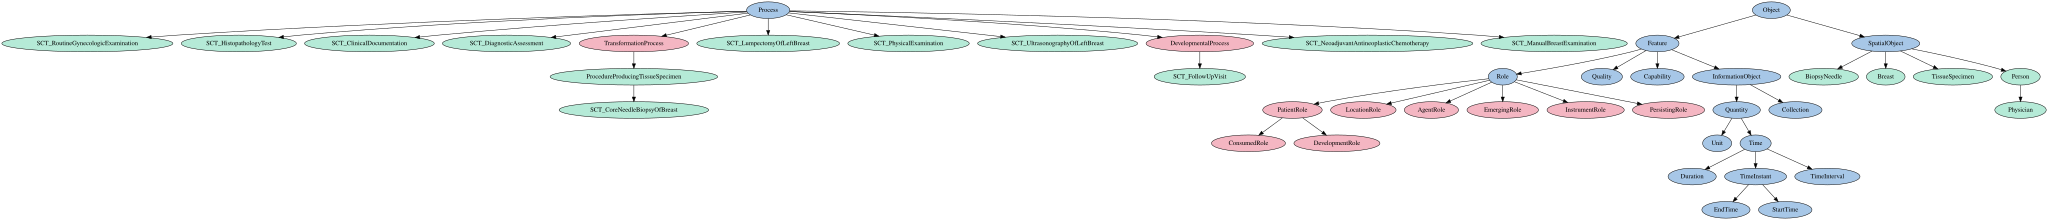

In [13]:
os.makedirs("dist", exist_ok=True)
mie.save(file="dist/mie-02.owl", format="rdfxml")
print("Saved dist/mie-02.owl")
print(f"  classes:                   {len(list(mie.classes()))}")
print(f"  individuals:               {len(list(mie.individuals()))}")
print(f"  object properties (local): {len(list(mie.object_properties()))}  ← still zero")
print(f"  imported ontologies:       {[o.base_iri for o in mie.imported_ontologies]}")

tree = get_color_tree([sulo, pro, mie])
display(tree)